# OSRM 连边验证实验（精细连边规则）

## 连边规则
1. **同位置站点** (abs_PM差 < 0.1 mi) 归为一组，组内不连边
2. **每个站点**连接上游和下游最近位置组的**所有站点**
3. **匝道特殊处理**:
   - OR (入口): 只连下游
   - FR (出口): 只连上游
4. **FF** (跨高速连接器): 单独标记，暂按普通规则处理

In [170]:
import pandas as pd
import numpy as np
import requests
import time
import os
import re
import glob
import json
from datetime import datetime
from math import radians, sin, cos, sqrt, atan2
from tqdm import tqdm
import matplotlib.pyplot as plt
import folium
from folium import plugins
import warnings
import networkx as nx
warnings.filterwarnings('ignore')

# ============== 配置 ==============
META_DIR = "../d03_meta"
OUTPUT_DIR = "../output/osrm_validation"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# OSRM 服务器
# OSRM_SERVER = "http://localhost:5000"  # 本地服务器
OSRM_SERVER = "http://router.project-osrm.org"  # 公共服务器

RATE_LIMIT_DELAY = 0.01  # 本地服务器几乎不需要延迟

# 同位置阈值（英里）
COLOCATION_THRESHOLD = 0.1

# 高速公路筛选（设为 None 则全量计算）
TARGET_FWY = "80"  # 只计算 I-80
TARGET_DIR = "E"   # 两个方向都算

print("配置完成！")
print(f"OSRM 服务器: {OSRM_SERVER}")
print(f"同位置阈值: {COLOCATION_THRESHOLD} mi")
print(f"目标高速: {TARGET_FWY if TARGET_FWY else '全部'}")

配置完成！
OSRM 服务器: http://router.project-osrm.org
同位置阈值: 0.1 mi
目标高速: 80


## 1. 加载元数据

In [171]:
# 查找最新的元数据文件
meta_files = glob.glob(os.path.join(META_DIR, "d03_text_meta_*.txt"))
if meta_files:
    meta_file = sorted(meta_files)[-1]
else:
    raise FileNotFoundError("未找到 D3 元数据文件")

print(f"使用元数据: {meta_file}")

META_COLUMNS = [
    'ID', 'Fwy', 'Dir', 'District', 'County', 'City',
    'State_PM', 'Abs_PM', 'Latitude', 'Longitude', 'Length',
    'Type', 'Lanes', 'Name', 'User_ID_1', 'User_ID_2',
    'User_ID_3', 'User_ID_4'
]

meta_df = pd.read_csv(
    meta_file, sep='\t', names=META_COLUMNS, header=0,
    dtype={'ID': str, 'Fwy': str}
)

print(f"总站点数: {len(meta_df)}")
print(f"\n各类型站点数:")
print(meta_df['Type'].value_counts())

使用元数据: ../d03_meta/d03_text_meta_2025_12_30.txt
总站点数: 1903

各类型站点数:
Type
ML    884
OR    431
HV    281
FR    279
FF     28
Name: count, dtype: int64


In [172]:
# 坐标有效性检查
def is_valid_coord(lat, lon):
    if pd.isna(lat) or pd.isna(lon):
        return False
    if not (32 <= lat <= 42):
        return False
    if not (-124 <= lon <= -114):
        return False
    return True

meta_df['Valid_Coord'] = meta_df.apply(
    lambda r: is_valid_coord(r['Latitude'], r['Longitude']), axis=1
)

print(f"有效坐标站点: {meta_df['Valid_Coord'].sum()} / {len(meta_df)}")

meta_valid = meta_df[meta_df['Valid_Coord']].copy()

# 应用高速公路筛选
if TARGET_FWY:
    meta_valid = meta_valid[meta_valid['Fwy'] == TARGET_FWY]
    print(f"筛选高速 {TARGET_FWY} 后: {len(meta_valid)} 站点")

if TARGET_DIR:
    meta_valid = meta_valid[meta_valid['Dir'] == TARGET_DIR]
    print(f"筛选方向 {TARGET_DIR} 后: {len(meta_valid)} 站点")

print(f"\n最终站点数: {len(meta_valid)}")
print(f"\n各类型站点数:")
print(meta_valid['Type'].value_counts())

有效坐标站点: 1901 / 1903
筛选高速 80 后: 480 站点
筛选方向 E 后: 245 站点

最终站点数: 245

各类型站点数:
Type
ML    105
OR     51
HV     45
FR     42
FF      2
Name: count, dtype: int64


## 2. 距离计算函数

In [173]:
def calc_distance_geo(lat1, lon1, lat2, lon2):
    """Haversine 直线距离（英里）"""
    R = 3958.8
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    return R * c


def calc_distance_osrm_with_geometry(lat1, lon1, lat2, lon2, server=OSRM_SERVER, timeout=10):
    """
    OSRM 最短路距离（单向），返回路径几何
    """
    url = f"{server}/route/v1/driving/{lon1},{lat1};{lon2},{lat2}"
    params = {
        "overview": "full",
        "geometries": "geojson",
        "steps": "false"
    }
    
    try:
        response = requests.get(url, params=params, timeout=timeout)
        data = response.json()
        
        if data.get("code") != "Ok":
            return {
                'distance_mi': None,
                'duration_min': None,
                'geometry': None,
                'status': 'no_route',
                'error_msg': data.get("code", "Unknown")
            }
        
        route = data["routes"][0]
        return {
            'distance_mi': route["distance"] / 1609.34,
            'duration_min': route["duration"] / 60,
            'geometry': route["geometry"],
            'status': 'ok',
            'error_msg': None
        }
        
    except Exception as e:
        return {
            'distance_mi': None,
            'duration_min': None,
            'geometry': None,
            'status': 'error',
            'error_msg': str(e)
        }


# 测试 OSRM 连接
print("测试 OSRM 服务器连接...")
test_result = calc_distance_osrm_with_geometry(38.5, -121.5, 38.6, -121.4, OSRM_SERVER)
if test_result['status'] == 'ok':
    print(f"✓ OSRM 服务器正常，测试距离: {test_result['distance_mi']:.2f} mi")
else:
    print(f"✗ OSRM 连接失败: {test_result['error_msg']}")
    print("请检查 OSRM 服务器是否启动")

测试 OSRM 服务器连接...
✓ OSRM 服务器正常，测试距离: 12.80 mi


## 3. 构建同位置组

In [174]:
def build_location_groups(sorted_group, threshold=0.1):
    """
    Group stations by exact Abs_PM equality.
    
    Returns: [(group_start_pm, [station_indices]), ...]
    """
    if len(sorted_group) == 0:
        return []
    
    groups = []
    current_group = [0]
    current_pm = sorted_group.iloc[0]['Abs_PM']
    
    for i in range(1, len(sorted_group)):
        pm = sorted_group.iloc[i]['Abs_PM']
        if pm == current_pm:
            current_group.append(i)
        else:
            groups.append((current_pm, current_group))
            current_group = [i]
            current_pm = pm
    
    groups.append((current_pm, current_group))
    return groups


 # 测试同位置组划分
test_fwy_dir = meta_valid.groupby(['Fwy', 'Dir']).first().index[0]
test_group = meta_valid[(meta_valid['Fwy'] == test_fwy_dir[0]) & 
                        (meta_valid['Dir'] == test_fwy_dir[1])].sort_values('Abs_PM').reset_index(drop=True)

test_loc_groups = build_location_groups(test_group, COLOCATION_THRESHOLD)
print(f"测试 Fwy {test_fwy_dir[0]}-{test_fwy_dir[1]}:")
print(f"  站点数: {len(test_group)}")
print(f"  位置组数: {len(test_loc_groups)}")
print(f"  多站点组数: {sum(1 for _, stations in test_loc_groups if len(stations) > 1)}")

# 显示前几个多站点组
print(f"\n多站点位置组示例:")
multi_count = 0
for pm, stations in test_loc_groups:
    if len(stations) > 1:
        print(f"  PM≈{pm:.3f}: {len(stations)} 站点")
        for idx in stations:
            s = test_group.iloc[idx]
            print(f"    - {s['ID']} ({s['Type']}) PM={s['Abs_PM']:.3f}")
        multi_count += 1
        if multi_count >= 3:
            break

测试 Fwy 80-E:
  站点数: 245
  位置组数: 194
  多站点组数: 31

多站点位置组示例:
  PM≈72.505: 3 站点
    - 318113 (ML) PM=72.505
    - 318114 (FR) PM=72.505
    - 318115 (OR) PM=72.505
  PM≈74.792: 3 站点
    - 314013 (ML) PM=74.792
    - 314014 (OR) PM=74.792
    - 314015 (FR) PM=74.792
  PM≈81.704: 2 站点
    - 318736 (FF) PM=81.704
    - 318135 (ML) PM=81.704


## 4. 构建连边（精细规则）

In [175]:
def build_edges_with_rules(meta_df, colocation_threshold=0.1):
    """
    根据精细规则构建连边
    
    规则:
    1. 同位置组内不连边
    2. 每个站点连接上游和下游最近的【可连接】位置组的所有站点
    3. OR (入口) 只连下游，不接受上游来的边
    4. FR (出口) 只连上游，不产生向下游的边
    5. 如果相邻组无法连接，跳过继续找下一个可连接的组
    6. FF 单独标记
    """
    all_edges = []
    group_info = []  # 记录位置组信息
    
    for (fwy, direction), fwy_group in tqdm(meta_df.groupby(['Fwy', 'Dir']), desc="构建连边"):
        sorted_group = fwy_group.sort_values('Abs_PM').reset_index(drop=True)
        n = len(sorted_group)
        
        if n < 2:
            continue
        
        # Step 1: 划分同位置组
        location_groups = build_location_groups(sorted_group, colocation_threshold)
        n_groups = len(location_groups)
        
        # 记录位置组信息
        for g_idx, (g_pm, g_stations) in enumerate(location_groups):
            types_in_group = [sorted_group.iloc[i]['Type'] for i in g_stations]
            group_info.append({
                'Fwy': fwy,
                'Dir': direction,
                'Group_Idx': g_idx,
                'Group_PM': g_pm,
                'N_Stations': len(g_stations),
                'Types': '+'.join(sorted(set(types_in_group))),
                'Station_IDs': [sorted_group.iloc[i]['ID'] for i in g_stations]
            })
        
        # Step 2: 为每个位置组构建连边
        for g_idx, (g_pm, g_stations) in enumerate(location_groups):
            
            for i in g_stations:
                station = sorted_group.iloc[i]
                station_type = station['Type']
                station_id = station['ID']
                
                # === 连接下游 (FR不连下游) ===
                if station_type != 'FR':
                    # 从下一个组开始找，直到找到可连接的目标
                    for ds_g_idx in range(g_idx + 1, n_groups):
                        ds_pm, ds_stations = location_groups[ds_g_idx]
                        connected = False
                        for j in ds_stations:
                            target = sorted_group.iloc[j]
                            # OR 不接受从上游来的边，跳过
                            if target['Type'] == 'OR':
                                continue
                            all_edges.append({
                                'Source_ID': station_id,
                                'Target_ID': target['ID'],
                                'Fwy': fwy,
                                'Dir': direction,
                                'Source_Type': station_type,
                                'Target_Type': target['Type'],
                                'Source_PM': station['Abs_PM'],
                                'Target_PM': target['Abs_PM'],
                                'PM_Diff': target['Abs_PM'] - station['Abs_PM'],
                                'Source_Lat': station['Latitude'],
                                'Source_Lon': station['Longitude'],
                                'Target_Lat': target['Latitude'],
                                'Target_Lon': target['Longitude'],
                                'Source_Name': station['Name'],
                                'Target_Name': target['Name'],
                                'Source_Lanes': station['Lanes'],
                                'Target_Lanes': target['Lanes'],
                                'Edge_Direction': 'downstream',
                                'Source_Group_Idx': g_idx,
                                'Target_Group_Idx': ds_g_idx,
                            })
                            connected = True
                        # 如果这个组有可连接的站点，停止搜索下游
                        if connected:
                            break
                
                # === 连接上游 (OR不连上游) ===
                if station_type != 'OR':
                    # 从上一个组开始往前找，直到找到可连接的来源
                    for us_g_idx in range(g_idx - 1, -1, -1):
                        us_pm, us_stations = location_groups[us_g_idx]
                        connected = False
                        for j in us_stations:
                            source = sorted_group.iloc[j]
                            # FR 不产生向下游的边，跳过
                            if source['Type'] == 'FR':
                                continue
                            # 注意这里的方向：上游站点 → 当前站点
                            all_edges.append({
                                'Source_ID': source['ID'],
                                'Target_ID': station_id,
                                'Fwy': fwy,
                                'Dir': direction,
                                'Source_Type': source['Type'],
                                'Target_Type': station_type,
                                'Source_PM': source['Abs_PM'],
                                'Target_PM': station['Abs_PM'],
                                'PM_Diff': station['Abs_PM'] - source['Abs_PM'],
                                'Source_Lat': source['Latitude'],
                                'Source_Lon': source['Longitude'],
                                'Target_Lat': station['Latitude'],
                                'Target_Lon': station['Longitude'],
                                'Source_Name': source['Name'],
                                'Target_Name': station['Name'],
                                'Source_Lanes': source['Lanes'],
                                'Target_Lanes': station['Lanes'],
                                'Edge_Direction': 'upstream',
                                'Source_Group_Idx': us_g_idx,
                                'Target_Group_Idx': g_idx,
                            })
                            connected = True
                        # 如果这个组有可连接的站点，停止搜索上游
                        if connected:
                            break
    
    edges_df = pd.DataFrame(all_edges)
    group_df = pd.DataFrame(group_info)
    
    # 去重（upstream 和 downstream 可能产生重复边）
    edges_df = edges_df.drop_duplicates(subset=['Source_ID', 'Target_ID'])
    
    return edges_df, group_df


# 构建连边
edges_df, group_df = build_edges_with_rules(meta_valid, COLOCATION_THRESHOLD)

print(f"\n连边结果:")
print(f"  总边数: {len(edges_df)}")
print(f"  位置组数: {len(group_df)}")
print(f"  多站点位置组: {(group_df['N_Stations'] > 1).sum()}")

构建连边: 100%|██████████| 1/1 [00:00<00:00, 10.02it/s]


连边结果:
  总边数: 289
  位置组数: 194
  多站点位置组: 31


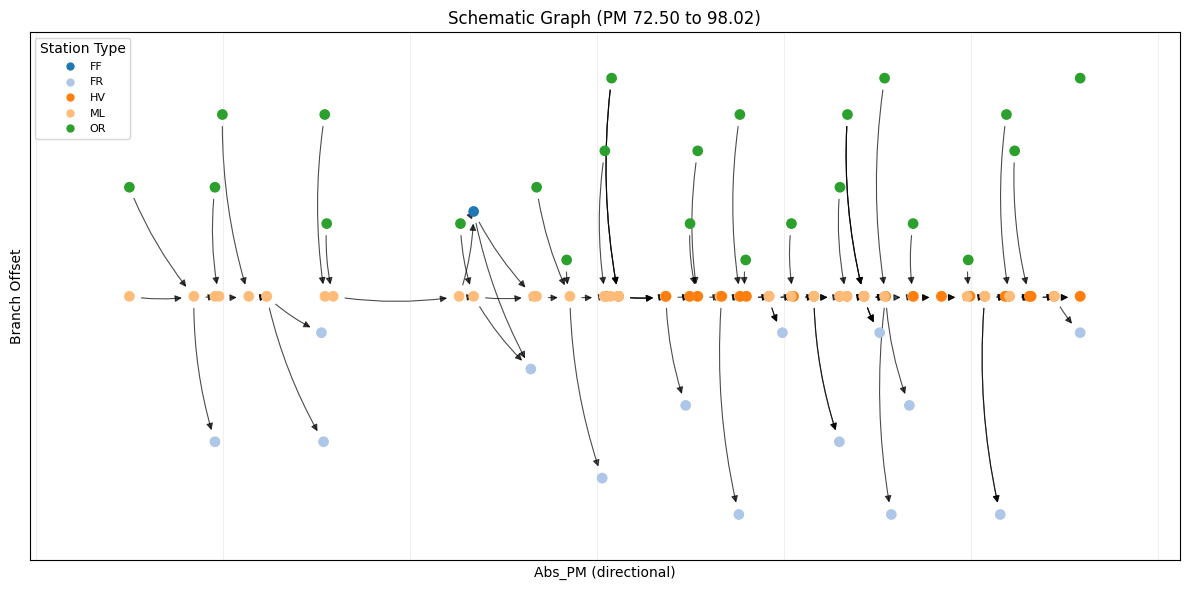

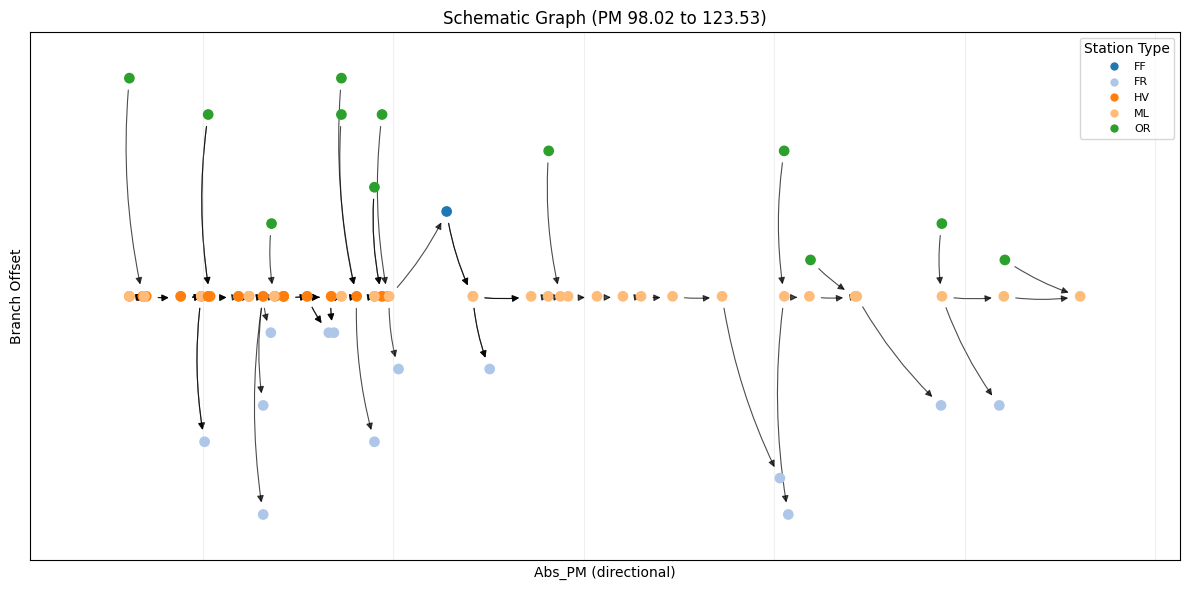

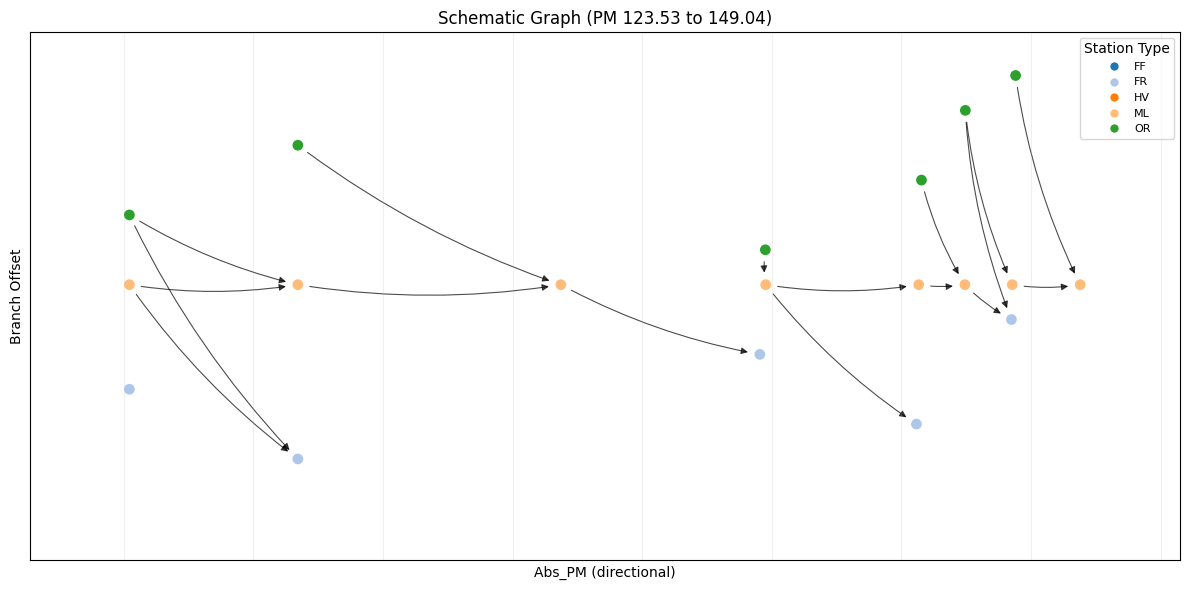

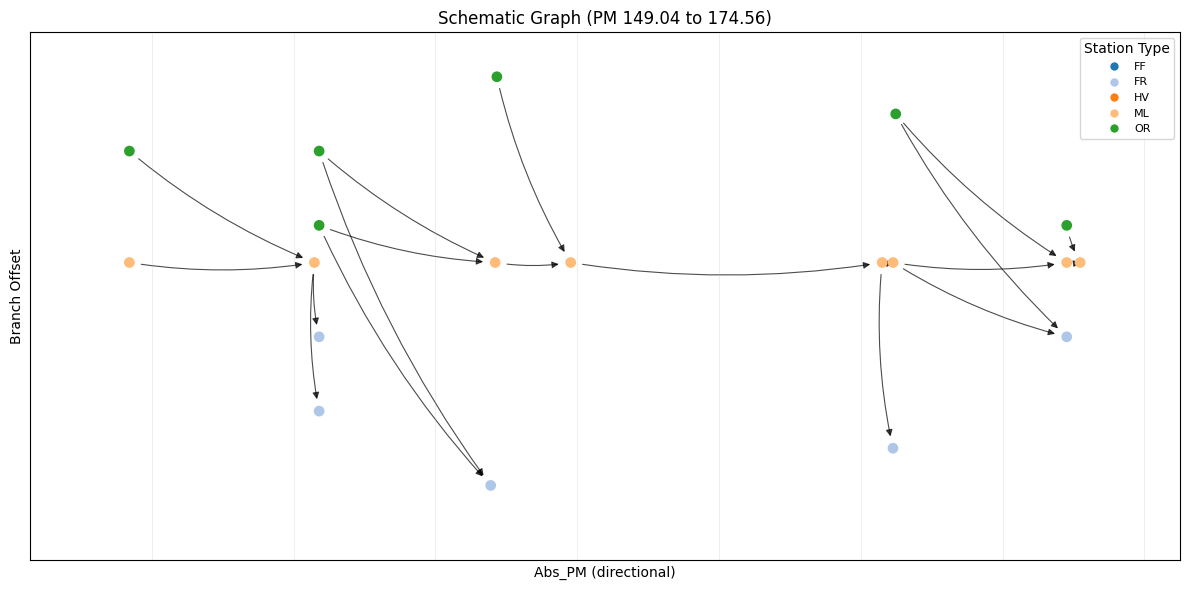

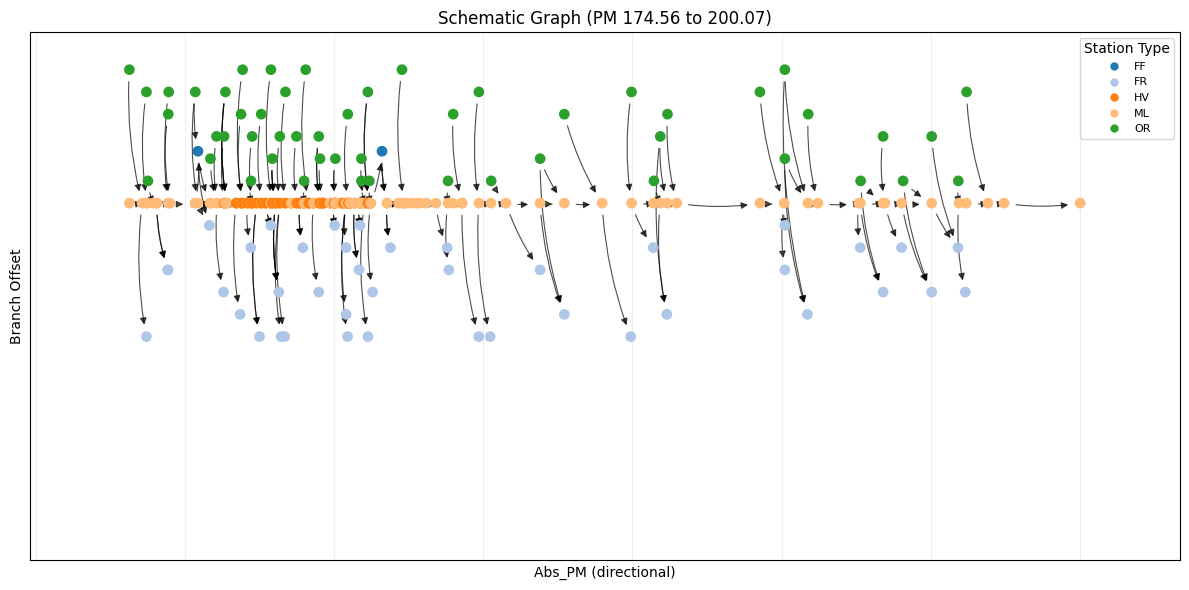

In [176]:
# Visualize schematic subgraphs by splitting the PM coverage into bins
mainline_types = {'ML', 'HV'}
ramp_types = {'FR', 'OR'}

G = nx.DiGraph()
node_info = {}

for _, row in edges_df.iterrows():
    for side in ['Source', 'Target']:
        node_id = row[f'{side}_ID']
        if node_id not in node_info:
            node_info[node_id] = {
                'abs_pm': float(row[f'{side}_PM']),
                'node_type': row[f'{side}_Type'],
                'dir': row['Dir'],
            }
    G.add_edge(row['Source_ID'], row['Target_ID'])

# PM coverage and bins
all_pms = [d['abs_pm'] for d in node_info.values()]
pm_min = float(np.min(all_pms))
pm_max = float(np.max(all_pms))
n_bins = 5
bin_edges = np.linspace(pm_min, pm_max, n_bins + 1)

# Color mapping (type -> color)
types_all = sorted({d['node_type'] for d in node_info.values()})
cmap = plt.get_cmap('tab20')
type_to_color = {t: cmap(i % 20) for i, t in enumerate(types_all)}

for i in range(n_bins):
    b_min = float(bin_edges[i])
    b_max = float(bin_edges[i + 1])
    # Include right edge only for last bin
    nodes_in_bin = {
        n for n, d in node_info.items()
        if (b_min <= d['abs_pm'] < b_max) or (i == n_bins - 1 and d['abs_pm'] <= b_max)
    }
    if not nodes_in_bin:
        continue
    G_bin = G.subgraph(nodes_in_bin).copy()
    node_info_bin = {n: node_info[n] for n in G_bin.nodes}

    # Build positions: mainline chain on y=0, ramps as branches
    ramp_nodes = [n for n, d in node_info_bin.items() if d['node_type'] in ramp_types]
    ramp_order = {n: idx for idx, n in enumerate(sorted(ramp_nodes))}
    pos = {}
    for n, d in node_info_bin.items():
        sign = 1.0 if d['dir'] in ['N', 'E'] else -1.0
        x = sign * d['abs_pm']
        if d['node_type'] in mainline_types:
            y = 0.0
        elif d['node_type'] == 'OR':
            y = 0.06 * (1 + ramp_order.get(n, 0) % 6)
        elif d['node_type'] == 'FR':
            y = -0.06 * (1 + ramp_order.get(n, 0) % 6)
        else:
            y = 0.14 * (1 + ramp_order.get(n, 0) % 4)
        pos[n] = (x, y)

    node_colors = [type_to_color[node_info_bin[n]['node_type']] for n in G_bin.nodes]

    fig, ax = plt.subplots(figsize=(12, 6))
    nx.draw_networkx_edges(
        G_bin, pos, ax=ax, width=0.8, alpha=0.7, arrows=True,
        arrowstyle='-|>', arrowsize=10, connectionstyle='arc3,rad=0.08',
    )
    nx.draw_networkx_nodes(G_bin, pos, ax=ax, node_size=45, node_color=node_colors)
    ax.set_xlabel('Abs_PM (directional)')
    ax.set_ylabel('Branch Offset')
    ax.set_title(f'Schematic Graph (PM {b_min:.2f} to {b_max:.2f})')
    ax.set_yticks([])
    ax.grid(True, axis='x', alpha=0.2)

    legend_handles = [
        plt.Line2D([0], [0], marker='o', color='w', label=t,
                   markerfacecolor=type_to_color[t], markersize=7)
        for t in types_all
    ]
    ax.legend(handles=legend_handles, title='Station Type', loc='best', fontsize=8)
    plt.tight_layout()
    fwy_suffix = f"_{TARGET_FWY}" if TARGET_FWY else ""
    plt.savefig(os.path.join(OUTPUT_DIR, f'schematic_graph{fwy_suffix}_bin{i+1}.png'), dpi=150)
    plt.show()

In [177]:
# 边的统计信息
print("边的类型组合统计:")
print(edges_df.groupby(['Source_Type', 'Target_Type']).size().sort_values(ascending=False))

print(f"\nPM 差值分布:")
print(edges_df['PM_Diff'].describe())

# 计算直线距离
edges_df['Dist_Geo'] = edges_df.apply(
    lambda r: calc_distance_geo(r['Source_Lat'], r['Source_Lon'], r['Target_Lat'], r['Target_Lon']),
    axis=1
)

print(f"\n直线距离分布:")
print(edges_df['Dist_Geo'].describe())

边的类型组合统计:
Source_Type  Target_Type
ML           ML             71
OR           ML             39
HV           ML             39
ML           HV             37
             FR             35
HV           HV             22
OR           HV             18
HV           FR             14
OR           FR              7
FF           ML              3
ML           FF              2
FF           FR              1
OR           FF              1
dtype: int64

PM 差值分布:
count    289.000000
mean       0.876225
std        1.361855
min        0.001000
25%        0.150000
50%        0.440000
75%        0.889000
max       11.160000
Name: PM_Diff, dtype: float64

直线距离分布:
count    289.000000
mean       0.825265
std        1.211174
min        0.000959
25%        0.149547
50%        0.440560
75%        0.843441
max       10.503267
Name: Dist_Geo, dtype: float64


## 5. OSRM 双向查询

In [178]:
def batch_osrm_query(edges_df, server=OSRM_SERVER, rate_limit=0.01):
    """
    批量 OSRM 双向查询
    """
    results = []
    
    for idx, row in tqdm(edges_df.iterrows(), total=len(edges_df), desc="OSRM查询"):
        # Source → Target (顺向)
        r_forward = calc_distance_osrm_with_geometry(
            row['Source_Lat'], row['Source_Lon'],
            row['Target_Lat'], row['Target_Lon'],
            server
        )
        if rate_limit > 0:
            time.sleep(rate_limit)
        
        # Target → Source (逆向)
        r_backward = calc_distance_osrm_with_geometry(
            row['Target_Lat'], row['Target_Lon'],
            row['Source_Lat'], row['Source_Lon'],
            server
        )
        if rate_limit > 0:
            time.sleep(rate_limit)
        
        results.append({
            'idx': idx,
            'OSRM_Forward_mi': r_forward['distance_mi'],
            'OSRM_Backward_mi': r_backward['distance_mi'],
            'OSRM_Forward_min': r_forward['duration_min'],
            'OSRM_Backward_min': r_backward['duration_min'],
            'Geometry_Forward': json.dumps(r_forward['geometry']) if r_forward['geometry'] else None,
            'Geometry_Backward': json.dumps(r_backward['geometry']) if r_backward['geometry'] else None,
            'Status_Forward': r_forward['status'],
            'Status_Backward': r_backward['status'],
        })
    
    return pd.DataFrame(results).set_index('idx')


fwy_suffix = f"_{TARGET_FWY}" if TARGET_FWY else ""
dir_suffix = f"_{TARGET_DIR}" if TARGET_DIR else ""
osrm_cache_file = os.path.join(OUTPUT_DIR, f"osrm_results{fwy_suffix}{dir_suffix}.csv")

if os.path.exists(osrm_cache_file):
    print(f"Load cached OSRM results: {osrm_cache_file}")
    osrm_results = pd.read_csv(osrm_cache_file, index_col="idx")
else:
    # 执行 OSRM 查询
    print(f"开始 OSRM 查询，共 {len(edges_df)} 条边...")
    est_time = len(edges_df) * 2 * max(RATE_LIMIT_DELAY, 0.005) / 60
    print(f"预计时间: {est_time:.1f} 分钟")
    print("="*60)

    osrm_results = batch_osrm_query(edges_df, OSRM_SERVER, RATE_LIMIT_DELAY)
    osrm_results.to_csv(osrm_cache_file, index=True, index_label="idx")
    print(f"OSRM results saved: {osrm_cache_file}")

# 合并结果
edges_df = edges_df.join(osrm_results)

print(f"\n查询完成!")
print(f"成功率 (顺向): {(edges_df['Status_Forward'] == 'ok').mean()*100:.1f}%")
print(f"成功率 (逆向): {(edges_df['Status_Backward'] == 'ok').mean()*100:.1f}%")

开始 OSRM 查询，共 289 条边...
预计时间: 0.1 分钟


OSRM查询:   0%|          | 0/289 [00:00<?, ?it/s]

OSRM查询: 100%|██████████| 289/289 [09:37<00:00,  2.00s/it]

OSRM results saved: ../output/osrm_validation/osrm_results_80_E.csv

查询完成!
成功率 (顺向): 100.0%
成功率 (逆向): 100.0%


## 6. 方向判断与一致性分析

In [179]:
# 只分析双向都成功的边
valid_edges = edges_df[
    (edges_df['Status_Forward'] == 'ok') & 
    (edges_df['Status_Backward'] == 'ok')
].copy()

print(f"双向都成功的边: {len(valid_edges)} / {len(edges_df)}")

双向都成功的边: 289 / 289


In [180]:
def determine_direction_by_pm(row):
    """
    根据 Abs_PM 和 Dir 判断车流方向
    
    我们的边是按 PM 递增方向构建的 (Source_PM < Target_PM)
    所以:
    - N/E 方向: 车流沿 PM 递增，即 Source → Target 是顺向
    - S/W 方向: 车流沿 PM 递减，即 Target → Source 是顺向
    
    返回: 'forward' (Source→Target是顺向) 或 'backward' (Target→Source是顺向)
    """
    direction = row['Dir']
    if direction in ['N', 'E']:
        return 'forward'
    else:
        return 'backward'


def determine_direction_by_osrm(row, threshold_ratio=0.8):
    """
    根据 OSRM 双向距离判断方向
    距离短的是顺向
    """
    d_forward = row['OSRM_Forward_mi']
    d_backward = row['OSRM_Backward_mi']
    
    if pd.isna(d_forward) or pd.isna(d_backward):
        return 'unknown'
    
    if d_forward < d_backward * threshold_ratio:
        return 'forward'
    elif d_backward < d_forward * threshold_ratio:
        return 'backward'
    else:
        return 'similar'


# 计算方向判断
valid_edges['Dir_by_PM'] = valid_edges.apply(determine_direction_by_pm, axis=1)
valid_edges['Dir_by_OSRM'] = valid_edges.apply(determine_direction_by_osrm, axis=1)
valid_edges['Direction_Match'] = valid_edges['Dir_by_PM'] == valid_edges['Dir_by_OSRM']

# 计算 OSRM 比值
valid_edges['OSRM_Min'] = valid_edges[['OSRM_Forward_mi', 'OSRM_Backward_mi']].min(axis=1)
valid_edges['OSRM_Max'] = valid_edges[['OSRM_Forward_mi', 'OSRM_Backward_mi']].max(axis=1)
valid_edges['OSRM_Ratio'] = valid_edges['OSRM_Max'] / valid_edges['OSRM_Min']

print("方向判断结果:")
print(f"\nPM 方向分布:")
print(valid_edges['Dir_by_PM'].value_counts())
print(f"\nOSRM 方向分布:")
print(valid_edges['Dir_by_OSRM'].value_counts())

方向判断结果:

PM 方向分布:
Dir_by_PM
forward    289
Name: count, dtype: int64

OSRM 方向分布:
Dir_by_OSRM
forward    284
similar      5
Name: count, dtype: int64


In [181]:
# 一致性统计
print("="*60)
print("方向判断一致性分析")
print("="*60)

# OSRM 有明确方向判断的
decisive = valid_edges[valid_edges['Dir_by_OSRM'].isin(['forward', 'backward'])].copy()
print(f"\nOSRM 有明确方向判断: {len(decisive)} / {len(valid_edges)} ({len(decisive)/len(valid_edges)*100:.1f}%)")

if len(decisive) > 0:
    match_count = decisive['Direction_Match'].sum()
    match_rate = match_count / len(decisive) * 100
    print(f"方向一致: {match_count} ({match_rate:.1f}%)")
    print(f"方向不一致: {len(decisive) - match_count} ({100-match_rate:.1f}%)")

# OSRM 双向相近的
similar = valid_edges[valid_edges['Dir_by_OSRM'] == 'similar']
print(f"\nOSRM 双向距离相近: {len(similar)} ({len(similar)/len(valid_edges)*100:.1f}%)")

方向判断一致性分析

OSRM 有明确方向判断: 284 / 289 (98.3%)
方向一致: 284 (100.0%)
方向不一致: 0 (0.0%)

OSRM 双向距离相近: 5 (1.7%)


In [182]:
# 找出方向判断不一致的边
mismatch = decisive[~decisive['Direction_Match']].copy()
print(f"\n方向不一致的边数: {len(mismatch)}")

if len(mismatch) > 0:
    print("\n不一致案例详情:")
    display_cols = [
        'Source_ID', 'Target_ID', 'Fwy', 'Dir', 
        'Source_Type', 'Target_Type',
        'Source_PM', 'Target_PM', 'PM_Diff', 'Dist_Geo',
        'OSRM_Forward_mi', 'OSRM_Backward_mi', 'OSRM_Ratio',
        'Dir_by_PM', 'Dir_by_OSRM',
        'Source_Name', 'Target_Name'
    ]
    display(mismatch[display_cols])


方向不一致的边数: 0


In [183]:
# 按类型组合分析
print("\n按站点类型组合分析:")
print("="*60)

type_stats = decisive.groupby(['Source_Type', 'Target_Type']).agg({
    'Direction_Match': ['sum', 'count']
}).reset_index()
type_stats.columns = ['Source_Type', 'Target_Type', 'Match', 'Total']
type_stats['Error_Rate'] = (1 - type_stats['Match'] / type_stats['Total']) * 100
type_stats = type_stats.sort_values('Total', ascending=False)

print(type_stats.to_string())


按站点类型组合分析:
   Source_Type Target_Type  Match  Total  Error_Rate
8           ML          ML     70     70         0.0
12          OR          ML     39     39         0.0
4           HV          ML     38     38         0.0
7           ML          HV     37     37         0.0
6           ML          FR     35     35         0.0
3           HV          HV     22     22         0.0
11          OR          HV     17     17         0.0
2           HV          FR     12     12         0.0
10          OR          FR      7      7         0.0
1           FF          ML      3      3         0.0
5           ML          FF      2      2         0.0
0           FF          FR      1      1         0.0
9           OR          FF      1      1         0.0


## 7. 可视化方向判断错误的边（OSM 底图）

In [184]:
def create_mismatch_map(mismatch_df, output_path, max_cases=100):
    """
    可视化方向判断错误的边
    """
    if len(mismatch_df) == 0:
        print("没有错误案例需要可视化")
        return None
    
    if len(mismatch_df) > max_cases:
        print(f"错误案例过多，只显示前 {max_cases} 个")
        mismatch_df = mismatch_df.head(max_cases)
    
    # 计算地图中心
    all_lats = list(mismatch_df['Source_Lat']) + list(mismatch_df['Target_Lat'])
    all_lons = list(mismatch_df['Source_Lon']) + list(mismatch_df['Target_Lon'])
    center_lat = np.mean(all_lats)
    center_lon = np.mean(all_lons)
    
    # 创建地图 (OSM 底图)
    m = folium.Map(
        location=[center_lat, center_lon],
        zoom_start=11,
        tiles='OpenStreetMap'
    )
    
    for idx, row in mismatch_df.iterrows():
        # Source 站点信息
        popup_source = f"""
        <b>Source (PM小)</b><br>
        ID: {row['Source_ID']}<br>
        Fwy: {row['Fwy']}-{row['Dir']}<br>
        Type: {row['Source_Type']}<br>
        Abs_PM: {row['Source_PM']:.3f}<br>
        Name: {row['Source_Name']}
        """
        
        # Target 站点信息
        popup_target = f"""
        <b>Target (PM大)</b><br>
        ID: {row['Target_ID']}<br>
        Fwy: {row['Fwy']}-{row['Dir']}<br>
        Type: {row['Target_Type']}<br>
        Abs_PM: {row['Target_PM']:.3f}<br>
        Name: {row['Target_Name']}
        """
        
        # 添加标记
        folium.Marker(
            [row['Source_Lat'], row['Source_Lon']],
            popup=folium.Popup(popup_source, max_width=300),
            tooltip=f"{row['Source_ID']} ({row['Source_Type']}) PM={row['Source_PM']:.2f}",
            icon=folium.Icon(color='green', icon='info-sign')
        ).add_to(m)
        
        folium.Marker(
            [row['Target_Lat'], row['Target_Lon']],
            popup=folium.Popup(popup_target, max_width=300),
            tooltip=f"{row['Target_ID']} ({row['Target_Type']}) PM={row['Target_PM']:.2f}",
            icon=folium.Icon(color='red', icon='info-sign')
        ).add_to(m)
        
        # 绘制顺向路径（蓝色）
        if row['Geometry_Forward']:
            geom = json.loads(row['Geometry_Forward'])
            coords = [[c[1], c[0]] for c in geom['coordinates']]
            folium.PolyLine(
                coords,
                color='blue',
                weight=4,
                opacity=0.8,
                tooltip=f"Forward: {row['OSRM_Forward_mi']:.2f} mi",
                popup=f"Source→Target: {row['OSRM_Forward_mi']:.2f} mi"
            ).add_to(m)
        
        # 绘制逆向路径（红色）
        if row['Geometry_Backward']:
            geom = json.loads(row['Geometry_Backward'])
            coords = [[c[1], c[0]] for c in geom['coordinates']]
            folium.PolyLine(
                coords,
                color='red',
                weight=4,
                opacity=0.6,
                tooltip=f"Backward: {row['OSRM_Backward_mi']:.2f} mi",
                popup=f"Target→Source: {row['OSRM_Backward_mi']:.2f} mi"
            ).add_to(m)
    
    # 图例
    legend_html = """
    <div style="position: fixed; bottom: 50px; left: 50px; z-index: 1000; 
                background-color: white; padding: 10px; border: 2px solid gray;
                border-radius: 5px; font-size: 14px;">
        <b>图例</b><br>
        <i class="fa fa-map-marker" style="color:green"></i> Source (PM小)<br>
        <i class="fa fa-map-marker" style="color:red"></i> Target (PM大)<br>
        <span style="color:blue">━━━</span> Source→Target<br>
        <span style="color:red">━━━</span> Target→Source<br>
        <br>
        <b>方向判断不一致:</b><br>
        PM判断与OSRM判断<br>
        的顺向方向相反
    </div>
    """
    m.get_root().html.add_child(folium.Element(legend_html))
    
    m.save(output_path)
    print(f"地图已保存: {output_path}")
    return m


# 生成错误案例地图
fwy_suffix = f"_{TARGET_FWY}" if TARGET_FWY else ""
if len(mismatch) > 0:
    mismatch_map = create_mismatch_map(
        mismatch,
        os.path.join(OUTPUT_DIR, f'edge_mismatch_map{fwy_suffix}.html'),
        max_cases=100
    )
else:
    print("没有方向判断错误的边")

没有方向判断错误的边


In [185]:
def create_all_edges_map(valid_edges_df, output_path, max_edges=500):
    """
    可视化所有边
    绿色: 方向一致
    红色: 方向不一致
    灰色: OSRM 无法判断
    """
    if len(valid_edges_df) > max_edges:
        print(f"边数过多，随机采样 {max_edges} 条")
        valid_edges_df = valid_edges_df.sample(n=max_edges, random_state=42)
    
    all_lats = list(valid_edges_df['Source_Lat']) + list(valid_edges_df['Target_Lat'])
    all_lons = list(valid_edges_df['Source_Lon']) + list(valid_edges_df['Target_Lon'])
    center_lat = np.mean(all_lats)
    center_lon = np.mean(all_lons)
    
    m = folium.Map(
        location=[center_lat, center_lon],
        zoom_start=10,
        tiles='OpenStreetMap',
    )
    
    # Mark all points (source/target)
    for idx, row in valid_edges_df.iterrows():
        source_popup = (
            f"<b>Source</b><br>"
            f"ID: {row['Source_ID']}<br>"
            f"Fwy: {row['Fwy']}-{row['Dir']}<br>"
            f"Type: {row['Source_Type']}<br>"
            f"Abs_PM: {row['Source_PM']:.3f}<br>"
            f"Name: {row['Source_Name']}"
        )
        target_popup = (
            f"<b>Target</b><br>"
            f"ID: {row['Target_ID']}<br>"
            f"Fwy: {row['Fwy']}-{row['Dir']}<br>"
            f"Type: {row['Target_Type']}<br>"
            f"Abs_PM: {row['Target_PM']:.3f}<br>"
            f"Name: {row['Target_Name']}"
        )
        folium.CircleMarker(
            [row['Source_Lat'], row['Source_Lon']],
            radius=2,
            color='blue',
            fill=True,
            fill_opacity=0.7,
            opacity=0.7,
            tooltip=f"{row['Source_ID']} | {row['Source_Type']} | PM={row['Source_PM']:.2f}",
            popup=folium.Popup(source_popup, max_width=300),
        ).add_to(m)
        folium.CircleMarker(
            [row['Target_Lat'], row['Target_Lon']],
            radius=2,
            color='orange',
            fill=True,
            fill_opacity=0.7,
            opacity=0.7,
            tooltip=f"{row['Target_ID']} | {row['Target_Type']} | PM={row['Target_PM']:.2f}",
            popup=folium.Popup(target_popup, max_width=300),
        ).add_to(m)
    
    for idx, row in valid_edges_df.iterrows():
        # 颜色选择
        if row['Dir_by_OSRM'] == 'similar':
            color = 'gray'
        elif row['Direction_Match']:
            color = 'green'
        else:
            color = 'red'
        
        # 取较短的路径显示
        if row['OSRM_Forward_mi'] <= row['OSRM_Backward_mi']:
            geom_str = row['Geometry_Forward']
            dist = row['OSRM_Forward_mi']
        else:
            geom_str = row['Geometry_Backward']
            dist = row['OSRM_Backward_mi']
        
        if geom_str:
            geom = json.loads(geom_str)
            coords = [[c[1], c[0]] for c in geom['coordinates']]
            folium.PolyLine(
                coords,
                color=color,
                weight=3,
                opacity=0.7,
                tooltip=f"{row['Source_ID']}->{row['Target_ID']}: {dist:.2f}mi ({row['Source_Type']}-{row['Target_Type']})",
            ).add_to(m)
    
    # 图例
    legend_html = """
    <div style="position: fixed; bottom: 50px; left: 50px; z-index: 1000; 
                background-color: white; padding: 10px; border: 2px solid gray;">
        <b>边颜色</b><br>
        <span style="color:green">━━━</span> 方向一致<br>
        <span style="color:red">━━━</span> 方向不一致<br>
        <span style="color:gray">━━━</span> OSRM无法判断<br>
        <br>
        <b>点颜色</b><br>
        <span style="color:blue">●</span> Source<br>
        <span style="color:orange">●</span> Target
    </div>
    """
    m.get_root().html.add_child(folium.Element(legend_html))
    
    m.save(output_path)
    print(f"全局地图已保存: {output_path}")
    return m


 # 生成全局地图
all_map = create_all_edges_map(
    valid_edges,
    os.path.join(OUTPUT_DIR, f'all_edges_map{fwy_suffix}.html'),
    max_edges=1000,
)

全局地图已保存: ../output/osrm_validation/all_edges_map_80.html


In [186]:
# 详细分析错误案例
def analyze_mismatch(row):
    """分析单个错误案例"""
    print("="*60)
    print(f"错误边: {row['Source_ID']} → {row['Target_ID']}")
    print("="*60)
    
    print(f"\n【高速信息】 Fwy {row['Fwy']}-{row['Dir']}")
    
    print(f"\n【Source 站点】")
    print(f"  ID: {row['Source_ID']}")
    print(f"  Type: {row['Source_Type']}")
    print(f"  Abs_PM: {row['Source_PM']:.3f}")
    print(f"  Name: {row['Source_Name']}")
    
    print(f"\n【Target 站点】")
    print(f"  ID: {row['Target_ID']}")
    print(f"  Type: {row['Target_Type']}")
    print(f"  Abs_PM: {row['Target_PM']:.3f}")
    print(f"  Name: {row['Target_Name']}")
    
    print(f"\n【距离】")
    print(f"  PM 差: {row['PM_Diff']:.3f} mi")
    print(f"  直线距离: {row['Dist_Geo']:.3f} mi")
    print(f"  OSRM Forward (S→T): {row['OSRM_Forward_mi']:.3f} mi")
    print(f"  OSRM Backward (T→S): {row['OSRM_Backward_mi']:.3f} mi")
    print(f"  OSRM 比值: {row['OSRM_Ratio']:.2f}")
    
    print(f"\n【方向判断】")
    print(f"  PM判断: {row['Dir_by_PM']}")
    print(f"  OSRM判断: {row['Dir_by_OSRM']}")
    
    print(f"\n【可能原因】")
    if row['Source_Type'] in ['FR', 'OR'] or row['Target_Type'] in ['FR', 'OR']:
        print("  → 涉及匝道 (FR/OR)")
    if row['Source_Type'] == 'HV' or row['Target_Type'] == 'HV':
        print("  → 涉及 HOV 车道")
    if row['Source_Type'] == 'FF' or row['Target_Type'] == 'FF':
        print("  → 涉及 FF 连接器")
    if row['OSRM_Ratio'] < 1.5:
        print("  → OSRM 双向距离接近，方向判断不明确")


if len(mismatch) > 0:
    print("\n" + "#"*60)
    print("# 错误案例详细分析")
    print("#"*60)
    
    for i in range(min(10, len(mismatch))):
        analyze_mismatch(mismatch.iloc[i])
        print()

## 8. 统计图表

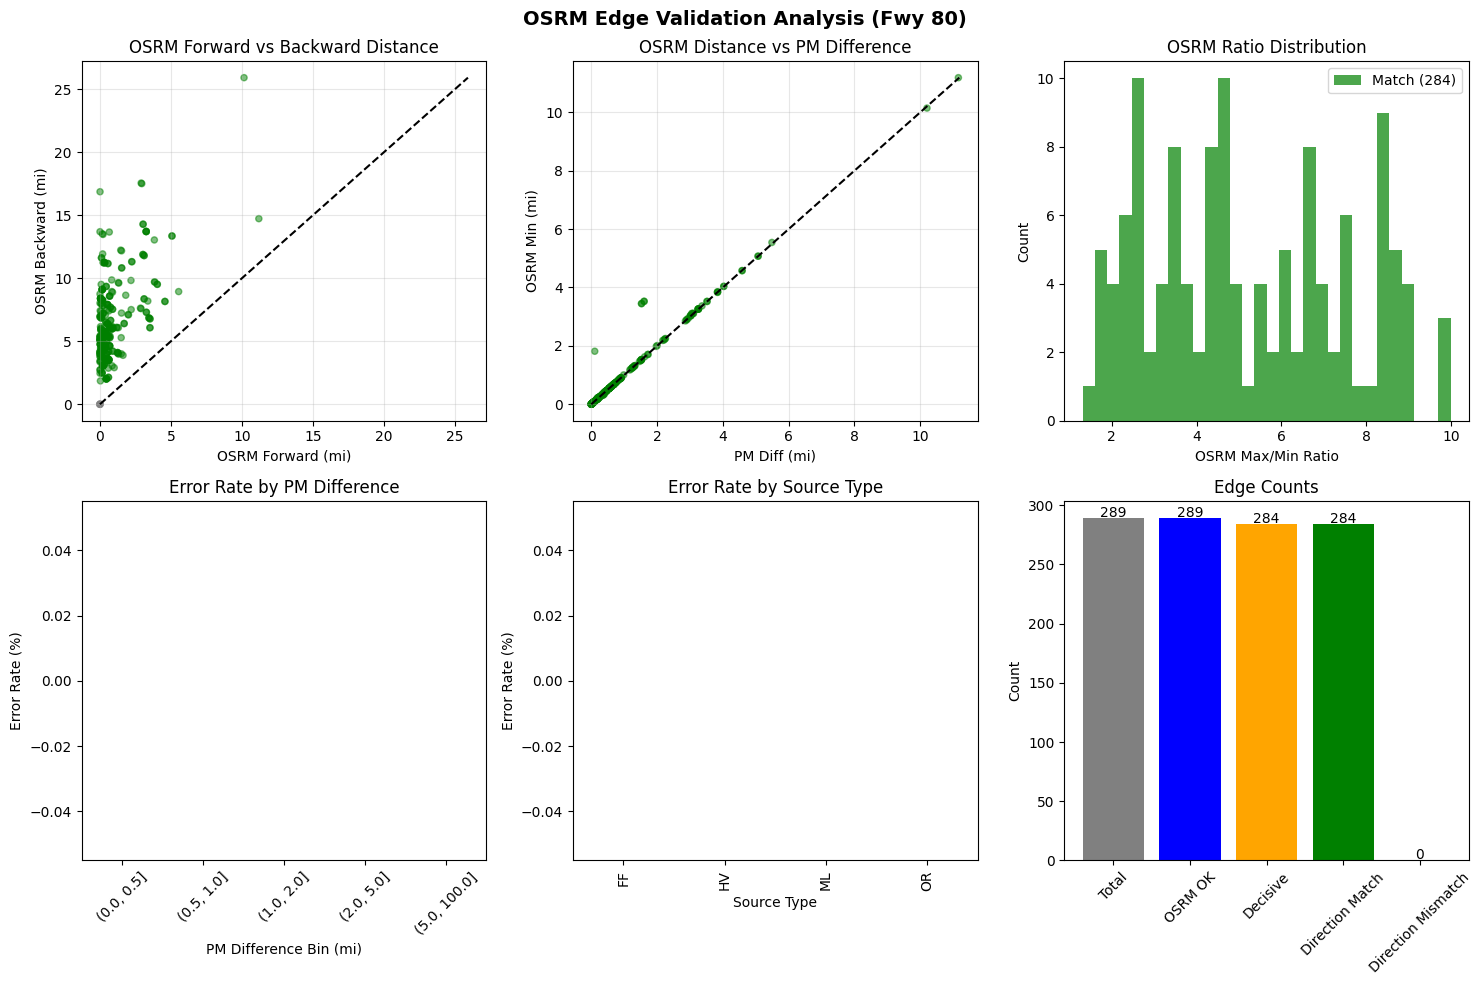

In [187]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. OSRM Forward vs Backward
ax = axes[0, 0]
colors = valid_edges['Direction_Match'].map({True: 'green', False: 'red'})
colors[valid_edges['Dir_by_OSRM'] == 'similar'] = 'gray'
ax.scatter(valid_edges['OSRM_Forward_mi'], valid_edges['OSRM_Backward_mi'], 
           c=colors, alpha=0.5, s=20)
max_val = max(valid_edges['OSRM_Forward_mi'].max(), valid_edges['OSRM_Backward_mi'].max())
ax.plot([0, max_val], [0, max_val], 'k--')
ax.set_xlabel('OSRM Forward (mi)')
ax.set_ylabel('OSRM Backward (mi)')
ax.set_title('OSRM Forward vs Backward Distance')
ax.grid(True, alpha=0.3)

# 2. OSRM vs PM_Diff
ax = axes[0, 1]
ax.scatter(valid_edges['PM_Diff'], valid_edges['OSRM_Min'], c=colors, alpha=0.5, s=20)
max_val = max(valid_edges['PM_Diff'].max(), valid_edges['OSRM_Min'].max())
ax.plot([0, max_val], [0, max_val], 'k--')
ax.set_xlabel('PM Diff (mi)')
ax.set_ylabel('OSRM Min (mi)')
ax.set_title('OSRM Distance vs PM Difference')
ax.grid(True, alpha=0.3)

# 3. OSRM Ratio Distribution
ax = axes[0, 2]
if len(decisive) > 0:
    match_ratio = decisive[decisive['Direction_Match']]['OSRM_Ratio']
    mismatch_ratio = decisive[~decisive['Direction_Match']]['OSRM_Ratio']
    if len(match_ratio) > 0:
        ax.hist(match_ratio[match_ratio < 10], bins=30, alpha=0.7, 
                label=f'Match ({len(match_ratio)})', color='green')
    if len(mismatch_ratio) > 0:
        ax.hist(mismatch_ratio[mismatch_ratio < 10], bins=30, alpha=0.7, 
                label=f'Mismatch ({len(mismatch_ratio)})', color='red')
ax.set_xlabel('OSRM Max/Min Ratio')
ax.set_ylabel('Count')
ax.set_title('OSRM Ratio Distribution')
ax.legend()

# 4. Error Rate by PM Difference
ax = axes[1, 0]
if len(decisive) > 0:
    decisive_copy = decisive.copy()
    decisive_copy['PM_Bin'] = pd.cut(decisive_copy['PM_Diff'], bins=[0, 0.5, 1, 2, 5, 100])
    error_by_pm = decisive_copy.groupby('PM_Bin')['Direction_Match'].agg(['sum', 'count'])
    error_by_pm['error_rate'] = (1 - error_by_pm['sum'] / error_by_pm['count']) * 100
    error_by_pm['error_rate'].plot(kind='bar', ax=ax, color='coral')
ax.set_xlabel('PM Difference Bin (mi)')
ax.set_ylabel('Error Rate (%)')
ax.set_title('Error Rate by PM Difference')
ax.tick_params(axis='x', rotation=45)

# 5. Error Rate by Source Type
ax = axes[1, 1]
if len(decisive) > 0:
    type_stats = decisive.groupby('Source_Type')['Direction_Match'].agg(['sum', 'count'])
    type_stats['error_rate'] = (1 - type_stats['sum'] / type_stats['count']) * 100
    type_stats['error_rate'].plot(kind='bar', ax=ax, color='steelblue')
ax.set_xlabel('Source Type')
ax.set_ylabel('Error Rate (%)')
ax.set_title('Error Rate by Source Type')

# 6. Edge Counts
ax = axes[1, 2]
stats = [
    len(edges_df),
    len(valid_edges),
    len(decisive),
    decisive['Direction_Match'].sum() if len(decisive) > 0 else 0,
    len(mismatch)
]
labels = ['Total', 'OSRM OK', 'Decisive', 'Direction Match', 'Direction Mismatch']
ax.bar(labels, stats, color=['gray', 'blue', 'orange', 'green', 'red'])
ax.set_ylabel('Count')
ax.set_title('Edge Counts')
ax.tick_params(axis='x', rotation=45)
for i, v in enumerate(stats):
    ax.text(i, v + 1, str(v), ha='center')

fwy_title = f" (Fwy {TARGET_FWY})" if TARGET_FWY else ""
plt.suptitle(f'OSRM Edge Validation Analysis{fwy_title}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'edge_analysis{fwy_suffix}.png'), dpi=150)
plt.show()

## 9. 保存结果

In [188]:
# 保存边结果（不含 geometry）
save_cols = [
    'Source_ID', 'Target_ID', 'Fwy', 'Dir',
    'Source_Type', 'Target_Type',
    'Source_PM', 'Target_PM', 'PM_Diff', 'Dist_Geo',
    'Source_Lat', 'Source_Lon', 'Target_Lat', 'Target_Lon',
    'OSRM_Forward_mi', 'OSRM_Backward_mi', 'OSRM_Min', 'OSRM_Max', 'OSRM_Ratio',
    'Dir_by_PM', 'Dir_by_OSRM', 'Direction_Match',
    'Source_Name', 'Target_Name',
    'Status_Forward', 'Status_Backward'
]

fwy_suffix = f"_{TARGET_FWY}" if TARGET_FWY else ""

# 保存所有边
edges_file = os.path.join(OUTPUT_DIR, f'edges_validation{fwy_suffix}.csv')
valid_edges[save_cols].to_csv(edges_file, index=False)
print(f"边结果已保存: {edges_file}")

# 保存错误边
if len(mismatch) > 0:
    mismatch_file = os.path.join(OUTPUT_DIR, f'edges_mismatch{fwy_suffix}.csv')
    mismatch[save_cols].to_csv(mismatch_file, index=False)
    print(f"错误边已保存: {mismatch_file}")

# 保存位置组信息
group_file = os.path.join(OUTPUT_DIR, f'location_groups{fwy_suffix}.csv')
group_df.to_csv(group_file, index=False)
print(f"位置组已保存: {group_file}")

边结果已保存: ../output/osrm_validation/edges_validation_80.csv
位置组已保存: ../output/osrm_validation/location_groups_80.csv


In [189]:
# 汇总报告
n_decisive = len(decisive) if len(decisive) > 0 else 0
n_match = decisive['Direction_Match'].sum() if n_decisive > 0 else 0
n_mismatch = len(mismatch) if len(mismatch) > 0 else 0

report = f"""
OSRM 连边验证报告（精细规则）
{'='*60}

配置:
  OSRM 服务器: {OSRM_SERVER}
  同位置阈值: {COLOCATION_THRESHOLD} mi
  目标高速: {TARGET_FWY if TARGET_FWY else '全部'}
  元数据文件: {meta_file}

连边规则:
  - 同位置组 (PM差<{COLOCATION_THRESHOLD}mi) 内不连边
  - 每个站点连接上下游最近位置组的所有站点
  - OR (入口) 只连下游
  - FR (出口) 只连上游

数据概况:
  站点数: {len(meta_valid)}
  位置组数: {len(group_df)}
  多站点位置组: {(group_df['N_Stations'] > 1).sum()}
  总边数: {len(edges_df)}
  OSRM 双向成功: {len(valid_edges)}

方向判断结果:
  OSRM有明确方向: {n_decisive}
  方向一致: {n_match} ({n_match/n_decisive*100:.1f}% if n_decisive > 0 else 0)
  方向不一致: {n_mismatch} ({n_mismatch/n_decisive*100:.1f}% if n_decisive > 0 else 0)
  OSRM双向相近: {len(similar)}

输出文件:
  - edges_validation{fwy_suffix}.csv: 所有边结果
  - edges_mismatch{fwy_suffix}.csv: 错误边
  - location_groups{fwy_suffix}.csv: 位置组信息
  - edge_mismatch_map{fwy_suffix}.html: 错误边地图
  - all_edges_map{fwy_suffix}.html: 全部边地图
  - edge_analysis{fwy_suffix}.png: 统计图表
"""

report_file = os.path.join(OUTPUT_DIR, f'edge_validation_report{fwy_suffix}.txt')
with open(report_file, 'w') as f:
    f.write(report)
print(f"报告已保存: {report_file}")
print(report)

报告已保存: ../output/osrm_validation/edge_validation_report_80.txt

OSRM 连边验证报告（精细规则）

配置:
  OSRM 服务器: http://router.project-osrm.org
  同位置阈值: 0.1 mi
  目标高速: 80
  元数据文件: ../d03_meta/d03_text_meta_2025_12_30.txt

连边规则:
  - 同位置组 (PM差<0.1mi) 内不连边
  - 每个站点连接上下游最近位置组的所有站点
  - OR (入口) 只连下游
  - FR (出口) 只连上游

数据概况:
  站点数: 245
  位置组数: 194
  多站点位置组: 31
  总边数: 289
  OSRM 双向成功: 289

方向判断结果:
  OSRM有明确方向: 284
  方向一致: 284 (100.0% if n_decisive > 0 else 0)
  方向不一致: 0 (0.0% if n_decisive > 0 else 0)
  OSRM双向相近: 5

输出文件:
  - edges_validation_80.csv: 所有边结果
  - edges_mismatch_80.csv: 错误边
  - location_groups_80.csv: 位置组信息
  - edge_mismatch_map_80.html: 错误边地图
  - all_edges_map_80.html: 全部边地图
  - edge_analysis_80.png: 统计图表

